# Индивидуальная работа 1
## Статистический анализ оценок видеоигр по данным Metacritic

**Студент:** Оксана Годорожа  
**Источник данных:** Kaggle — Metacritic Video Games Reviews (up to Sep 2025)  
**Инструмент:** Python 3, Jupyter Notebook


## I. Введение

**Цель анализа:** исследовать структуру оценок видеоигр на платформе Metacritic, выявить статистические закономерности между оценками критиков (Metascore) и пользователей (User Score), а также проверить гипотезы о влиянии жанра и платформы на качество игр.

**Статистические задачи:**
1. Описать распределение Metascore и User Score, выявить основные тенденции
2. Построить доверительные интервалы для средних оценок
3. Проверить корреляцию между оценками критиков и пользователей (Pearson, Spearman)
4. Проверить различие средних оценок между жанрами и платформами (ANOVA)
5. Проверить зависимость между категориями оценок критиков и пользователей (χ²)
6. Проверить значимость различия средних (t-тест: Metascore vs User Score)

**Описание набора данных:**

| Переменная | Тип | Описание |
|---|---|---|
| `name` | Категориальная | Название игры |
| `platform` | Категориальная | Игровая платформа |
| `release_date` | Дата | Дата выхода игры |
| `metascore` | Числовая | Оценка критиков (0–100) |
| `user_score` | Числовая | Оценка пользователей (0–10) |
| `developer` | Категориальная | Разработчик игры |
| `genre` | Категориальная | Жанр игры |
| `score_category` | Категориальная | Категория Metascore (Negative/Neutral/Positive) |
| `user_score_category` | Категориальная | Категория User Score (Negative/Neutral/Positive) |

> **Источник:** Kaggle, датасет `stadynromn/metacritic-video-games-reviews-up-to-sep-2025`, 22 224 записи


## Загрузка библиотек и данных

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro, levene, f_oneway, chi2_contingency, ttest_ind
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('metacritic_dataset_clean.csv')

# Derived columns
df['score_category'] = df['metascore'].apply(
    lambda s: 'Negative' if s < 60 else ('Neutral' if s < 75 else 'Positive'))
df['user_score_category'] = df['user_score'].apply(
    lambda s: 'Negative' if s < 5 else ('Neutral' if s < 7.5 else 'Positive'))
df['score_diff'] = df['metascore'] - (df['user_score'] * 10)
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

print(f"Датасет загружен: {df.shape[0]} игр, {df.shape[1]} переменных")
df[['name','platform','metascore','user_score','genre']].head()


Датасет загружен: 22224 игр, 12 переменных


,name,platform,metascore,user_score,genre
0,The Legend of Zelda: Ocarina of Time,Nintendo 64,99.0,9.1,Open-World Action
1,SoulCalibur,Dreamcast,98.0,7.6,3D Fighting
2,SoulCalibur,iOS (iPhone/iPad),73.0,7.8,3D Fighting
3,SoulCalibur,Xbox 360,79.0,7.3,3D Fighting
4,Grand Theft Auto IV,PlayStation 3,98.0,8.0,Open-World Action


## II. Описательный анализ и визуализация
### 2.1 Описательные статистики числовых переменных

In [3]:
desc = df[['metascore','user_score','score_diff']].agg(['mean','median','std','min','max']).round(4)
desc.index = ['Среднее','Медиана','Ст. отклонение','Минимум','Максимум']
desc


,metascore,user_score,score_diff
Среднее,72.0058,6.8491,3.5151
Медиана,74.0000,7.1000,3.0000
Ст. отклонение,11.9007,1.3930,12.7897
Минимум,11.0000,0.2000,-52.0000
Максимум,99.0000,10.0000,72.0000


### 2.2 Частоты категориальных переменных

In [4]:
for col in ['score_category','user_score_category']:
    freq = df[col].value_counts()
    prop = (df[col].value_counts(normalize=True)*100).round(2)
    print(f"\n{'='*45}\n  {col}\n{'='*45}")
    print(pd.DataFrame({'Количество': freq, 'Процент (%)': prop}))



  score_category
                Количество  Процент (%)
score_category                         
Positive             10593        47.66
Neutral               8481        38.16
Negative              3150        14.17

  user_score_category
                     Количество  Процент (%)
user_score_category                         
Neutral                   11415        51.36
Positive                   8644        38.89
Negative                   2165         9.74


### 2.3 Визуализация: гистограммы

Гистограммы показывают распределение ключевых числовых переменных.

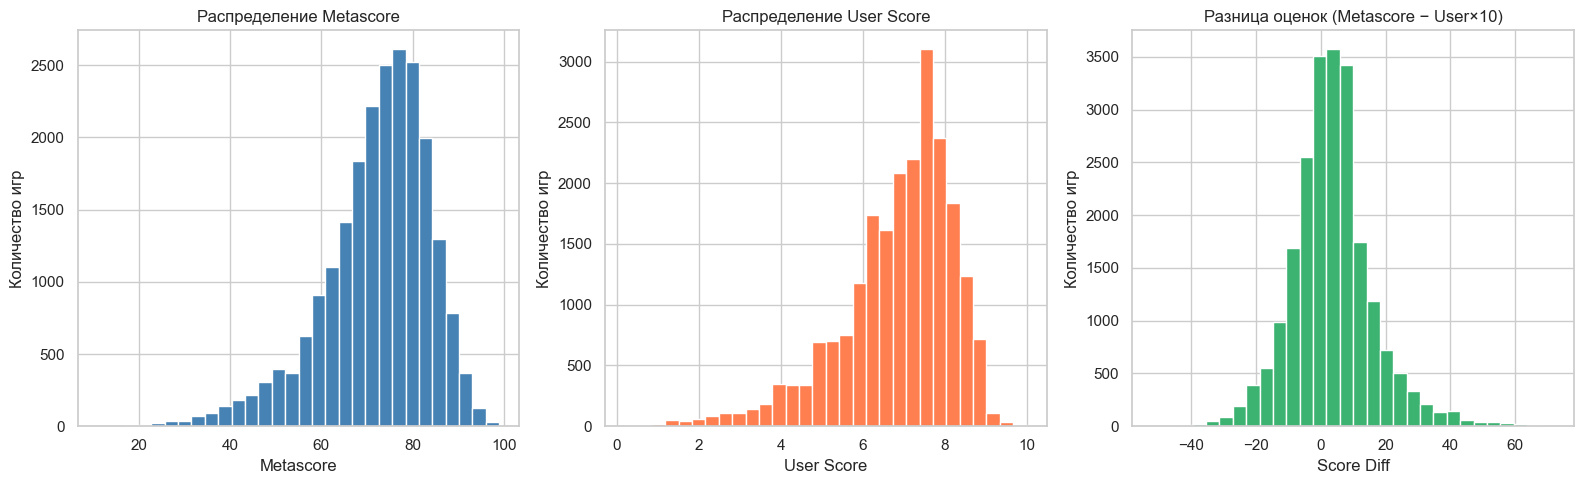

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df['metascore'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение Metascore')
axes[0].set_xlabel('Metascore'); axes[0].set_ylabel('Количество игр')

axes[1].hist(df['user_score'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Распределение User Score')
axes[1].set_xlabel('User Score'); axes[1].set_ylabel('Количество игр')

axes[2].hist(df['score_diff'], bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Разница оценок (Metascore − User×10)')
axes[2].set_xlabel('Score Diff'); axes[2].set_ylabel('Количество игр')

plt.tight_layout()
plt.savefig('plot_histograms.png', dpi=150)
plt.show()


### 2.4 Визуализация: категории оценок (столбчатые диаграммы)

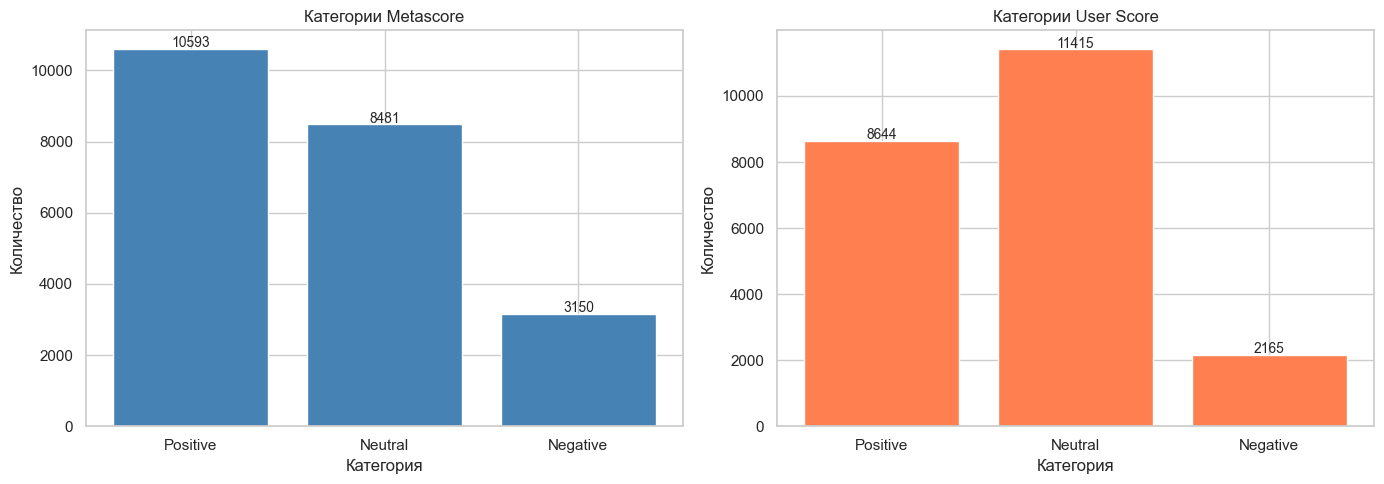

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title, color in zip(
    axes,
    ['score_category', 'user_score_category'],
    ['Категории Metascore', 'Категории User Score'],
    ['steelblue', 'coral']
):
    vc = df[col].value_counts()
    order = ['Positive','Neutral','Negative']
    ax.bar([o for o in order if o in vc.index],
           [vc.get(o,0) for o in order if o in vc.index], color=color)
    ax.set_title(title); ax.set_xlabel('Категория'); ax.set_ylabel('Количество')
    for i, (k,v) in enumerate([(o, vc.get(o,0)) for o in order if o in vc.index]):
        ax.text(i, v+50, f'{v}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('plot_categories.png', dpi=150)
plt.show()


## III. Проверка нормальности распределения

**Тест Шапиро-Уилка** применяется для каждой числовой переменной.  
Из-за большого объёма выборки (22 224) используется случайная подвыборка 5 000 наблюдений.

- **H₀:** Данные распределены нормально  
- **H₁:** Данные НЕ распределены нормально  
- **α = 0.05**


In [8]:
sample = df.sample(5000, random_state=42)
print("Тест Шапиро-Уилка (подвыборка n=5000)\n" + "="*50)
for col in ['metascore', 'user_score', 'score_diff']:
    stat, p = shapiro(sample[col].dropna())
    verdict = "нормальное" if p > 0.05 else "НЕ нормальное"
    print(f"  {col:15s}: W={stat:.4f}, p={p:.4f}  →  {verdict}")


Тест Шапиро-Уилка (подвыборка n=5000)
  metascore      : W=0.9517, p=0.0000  →  НЕ нормальное
  user_score     : W=0.9307, p=0.0000  →  НЕ нормальное
  score_diff     : W=0.9646, p=0.0000  →  НЕ нормальное


## IV. Доверительные интервалы

Строим 95%-е доверительные интервалы для среднего Metascore и среднего User Score.


In [9]:
alpha = 0.05
print(f"{'='*55}")
print(f"{'Переменная':20s} {'Среднее':>10} {'95% ДИ':>25}")
print(f"{'='*55}")
for col, label in [('metascore','Metascore'), ('user_score','User Score')]:
    data = df[col].dropna()
    n, m, se = len(data), data.mean(), stats.sem(data)
    ci = stats.t.interval(1-alpha, df=n-1, loc=m, scale=se)
    print(f"  {label:18s} {m:>10.4f}   [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"{'='*55}")


Переменная              Среднее                    95% ДИ
  Metascore             72.0058   [71.8494, 72.1623]
  User Score             6.8491   [6.8308, 6.8674]


## V. Корреляционный анализ

**Вопрос:** Существует ли связь между оценками критиков (Metascore) и пользователей (User Score)?

- **H₀:** r = 0 — корреляция отсутствует  
- **H₁:** r ≠ 0 — корреляция значима  
- **α = 0.05**


In [11]:
r_p, p_p = stats.pearsonr(df['metascore'], df['user_score'])
r_s, p_s = stats.spearmanr(df['metascore'], df['user_score'])

print("Корреляция: Metascore vs User Score\n" + "="*45)
print(f"  Pearson  r   = {r_p:.4f},  p = {p_p:.4f}  {'→ значимо ' if p_p < 0.05 else '→ незначимо'}")
print(f"  Spearman rho = {r_s:.4f},  p = {p_s:.4f}  {'→ значимо ' if p_s < 0.05 else '→ незначимо'}")

alpha = 0.05
print(f"\nВывод: p={p_p:.4f} {'< ' if p_p < alpha else '>= '}α={alpha} → {'ОТВЕРГАЕМ H₀ — корреляция значима.' if p_p < alpha else 'НЕ ОТВЕРГАЕМ H₀.'}")


Корреляция: Metascore vs User Score
  Pearson  r   = 0.5191,  p = 0.0000  → значимо 
  Spearman rho = 0.5125,  p = 0.0000  → значимо 

Вывод: p=0.0000 < α=0.05 → ОТВЕРГАЕМ H₀ — корреляция значима.


### Визуализация корреляции

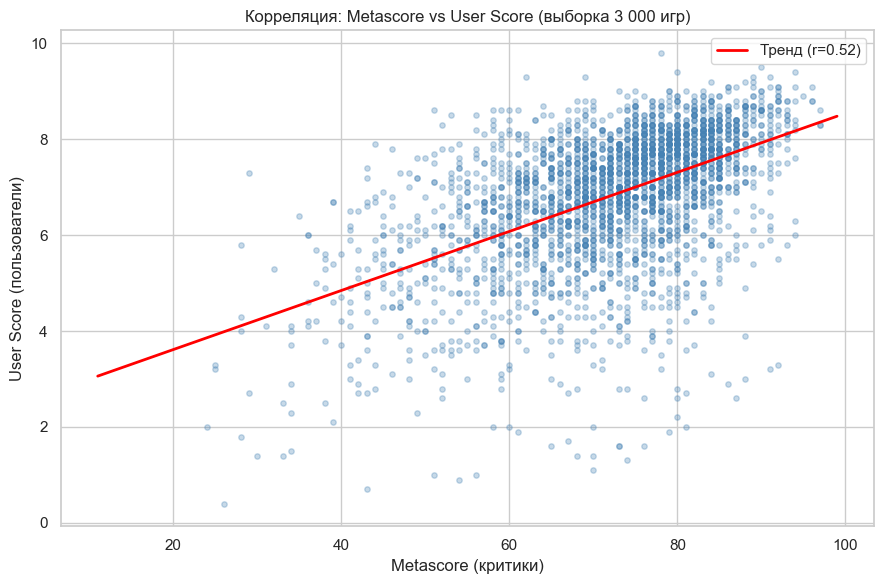

In [12]:
sample_plot = df.sample(3000, random_state=42)
plt.figure(figsize=(9, 6))
plt.scatter(sample_plot['metascore'], sample_plot['user_score'], alpha=0.3, s=15, color='steelblue')
m_coef, b_coef = np.polyfit(sample_plot['metascore'], sample_plot['user_score'], 1)
x_line = np.linspace(df['metascore'].min(), df['metascore'].max(), 100)
plt.plot(x_line, m_coef*x_line + b_coef, color='red', linewidth=2, label=f'Тренд (r={r_p:.2f})')
plt.xlabel('Metascore (критики)'); plt.ylabel('User Score (пользователи)')
plt.title('Корреляция: Metascore vs User Score (выборка 3 000 игр)')
plt.legend(); plt.tight_layout()
plt.savefig('plot_correlation.png', dpi=150)
plt.show()


## VI. T-тест: Metascore vs User Score

**Вопрос:** Значимо ли отличаются средние оценки критиков и пользователей?

- **H₀:** μ(Metascore) = μ(User Score × 10) — средние равны  
- **H₁:** μ(Metascore) ≠ μ(User Score × 10) — средние различаются  
- **α = 0.05**


In [13]:
t_stat, p_t = ttest_ind(df['metascore'], df['user_score'] * 10)

print(f"Средний Metascore      : {df['metascore'].mean():.4f}")
print(f"Средний User Score × 10: {(df['user_score']*10).mean():.4f}")
print(f"\nt-статистика: {t_stat:.4f}")
print(f"p-значение  : {p_t:.4f}")

alpha = 0.05
if p_t < alpha:
    print(f"\nВывод: p={p_t:.4f} < α={alpha} → ОТВЕРГАЕМ H₀")
    print("Критики и пользователи оценивают игры значимо по-разному.")
    print("Критики в среднем ставят более высокие оценки (72.0 vs 68.5 по шкале 0–100).")
else:
    print(f"\nВывод: p={p_t:.4f} >= α={alpha} → НЕ ОТВЕРГАЕМ H₀")


Средний Metascore      : 72.0058
Средний User Score × 10: 68.4907

t-статистика: 28.6016
p-значение  : 0.0000

Вывод: p=0.0000 < α=0.05 → ОТВЕРГАЕМ H₀
Критики и пользователи оценивают игры значимо по-разному.
Критики в среднем ставят более высокие оценки (72.0 vs 68.5 по шкале 0–100).


## VII. Критерий хи-квадрат: зависимость категорий оценок

**Вопрос:** Зависит ли категория оценки критиков от категории оценки пользователей?

- **H₀:** Категории оценок критиков и пользователей независимы  
- **H₁:** Категории оценок статистически зависимы  
- **α = 0.05**


In [14]:
ct = pd.crosstab(df['score_category'], df['user_score_category'],
                 margins=True, margins_name='Итого')
print("Таблица сопряжённости: Metascore × User Score Categories")
print(ct)

ct_clean = pd.crosstab(df['score_category'], df['user_score_category'])
chi2, p_chi, dof, expected = chi2_contingency(ct_clean)

print(f"\nχ²-статистика  : {chi2:.4f}")
print(f"Степени свободы: {dof}")
print(f"p-значение     : {p_chi:.4f}")

alpha = 0.05
if p_chi < alpha:
    print(f"\nВывод: p={p_chi:.4f} < α={alpha} → ОТВЕРГАЕМ H₀")
    print("Категории оценок критиков и пользователей статистически зависимы.")
    print("Игры с высоким Metascore также чаще получают высокие оценки от пользователей.")
else:
    print(f"\nВывод: p={p_chi:.4f} >= α={alpha} → НЕ ОТВЕРГАЕМ H₀")


Таблица сопряжённости: Metascore × User Score Categories
user_score_category  Negative  Neutral  Positive  Итого
score_category                                         
Negative                  989     1831       330   3150
Neutral                   806     5516      2159   8481
Positive                  370     4068      6155  10593
Итого                    2165    11415      8644  22224

χ²-статистика  : 4677.5611
Степени свободы: 4
p-значение     : 0.0000

Вывод: p=0.0000 < α=0.05 → ОТВЕРГАЕМ H₀
Категории оценок критиков и пользователей статистически зависимы.
Игры с высоким Metascore также чаще получают высокие оценки от пользователей.


## VIII. Дисперсионный анализ — ANOVA по жанрам

**Вопрос:** Различается ли средний Metascore между жанрами игр?

- **H₀:** μ₁ = μ₂ = ... = μₖ — средний Metascore одинаков для всех жанров  
- **H₁:** Хотя бы один жанр значимо отличается  
- **Обоснование ANOVA:** сравниваем более 2 групп  
- **α = 0.05**


In [17]:
top_genres = df['genre'].value_counts().head(6).index.tolist()
df_g = df[df['genre'].isin(top_genres)]
groups_g = [df_g[df_g['genre']==g]['metascore'].dropna() for g in top_genres]

print("Описательная статистика по жанрам:\n" + "="*55)
for g, data in zip(top_genres, groups_g):
    print(f"  {g:22s}: n={len(data):4d}, μ={np.mean(data):.2f}, σ={np.std(data):.2f}")

print("\nТест Шапиро-Уилка (нормальность):\n" + "="*55)
for g, data in zip(top_genres, groups_g):
    w, p = shapiro(data.sample(min(len(data),500), random_state=42))
    verdict = "нормальное" if p > 0.05 else "НЕ нормальное"
    print(f"  {g:22s}: W={w:.4f}, p={p:.4f}  →  {verdict}")

lev_stat, lev_p = levene(*groups_g)
print(f"\nТест Левена: W={lev_stat:.4f}, p={lev_p:.4f}  →  {'Дисперсии однородны ' if lev_p >= 0.05 else 'Дисперсии неоднородны '}")

f_stat, p_anova = f_oneway(*groups_g)
print(f"\nANOVA:")
print(f"  F-статистика : {f_stat:.4f}")
print(f"  p-значение   : {p_anova:.4f}")
alpha = 0.05
if p_anova < alpha:
    print(f"\nВывод: p={p_anova:.4f} < α={alpha} → ОТВЕРГАЕМ H₀")
    print("Средний Metascore значимо различается между жанрами.")
else:
    print(f"\nВывод: p={p_anova:.4f} >= α={alpha} → НЕ ОТВЕРГАЕМ H₀")


Описательная статистика по жанрам:
  Action Adventure      : n=1645, μ=69.05, σ=13.31
  Action RPG            : n=1215, μ=72.80, σ=11.27
  2D Platformer         : n=1134, μ=74.05, σ=10.47
  FPS                   : n=1131, μ=71.83, σ=13.41
  Open-World Action     : n= 823, μ=74.17, σ=11.58
  Survival              : n= 737, μ=69.93, σ=11.97

Тест Шапиро-Уилка (нормальность):
  Action Adventure      : W=0.9653, p=0.0000  →  НЕ нормальное
  Action RPG            : W=0.9602, p=0.0000  →  НЕ нормальное
  2D Platformer         : W=0.9573, p=0.0000  →  НЕ нормальное
  FPS                   : W=0.9467, p=0.0000  →  НЕ нормальное
  Open-World Action     : W=0.9452, p=0.0000  →  НЕ нормальное
  Survival              : W=0.9443, p=0.0000  →  НЕ нормальное

Тест Левена: W=17.4145, p=0.0000  →  Дисперсии неоднородны 

ANOVA:
  F-статистика : 35.8903
  p-значение   : 0.0000

Вывод: p=0.0000 < α=0.05 → ОТВЕРГАЕМ H₀
Средний Metascore значимо различается между жанрами.


### Post-hoc анализ Тьюки (попарные сравнения жанров)

In [18]:
tukey = pairwise_tukeyhsd(df_g['metascore'], df_g['genre'], alpha=0.05)
print(tukey.summary())


           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1            group2      meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------
    2D Platformer  Action Adventure  -5.0004    0.0 -6.3395 -3.6612   True
    2D Platformer        Action RPG  -1.2529 0.1263 -2.6855  0.1798  False
    2D Platformer               FPS  -2.2218 0.0002 -3.6799 -0.7637   True
    2D Platformer Open-World Action   0.1157 0.9999 -1.4732  1.7045  False
    2D Platformer          Survival  -4.1253    0.0  -5.767 -2.4836   True
 Action Adventure        Action RPG   3.7475    0.0   2.435    5.06   True
 Action Adventure               FPS   2.7786    0.0  1.4383  4.1188   True
 Action Adventure Open-World Action    5.116    0.0  3.6346  6.5974   True
 Action Adventure          Survival   0.8751  0.584 -0.6629   2.413  False
       Action RPG               FPS  -0.9689 0.3858 -2.4025  0.4647  False
       Action RPG Open-Wo

### Визуализация ANOVA по жанрам

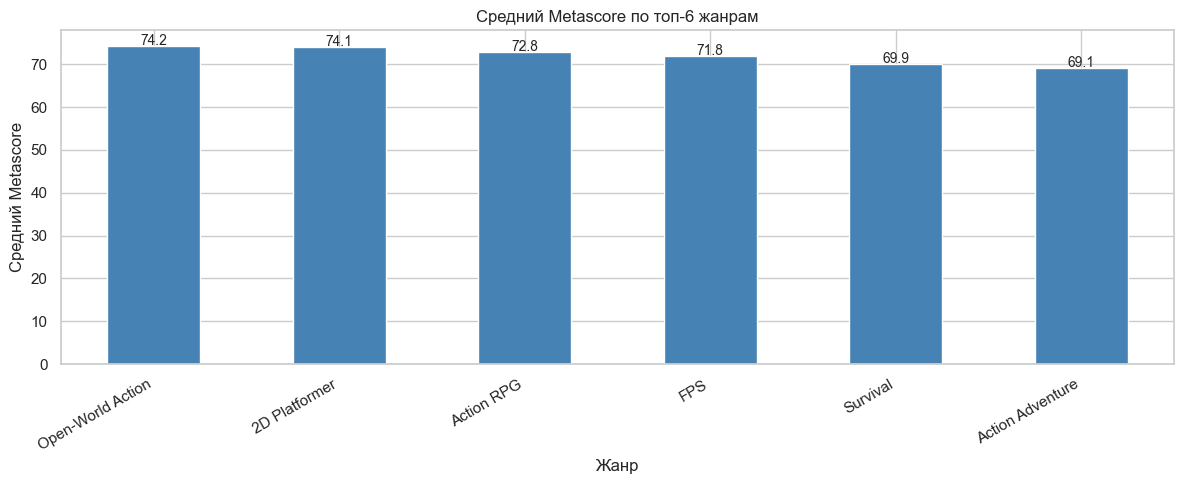

In [19]:
genre_avg = df_g.groupby('genre')['metascore'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
genre_avg.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Средний Metascore по топ-6 жанрам')
plt.xlabel('Жанр'); plt.ylabel('Средний Metascore')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(genre_avg):
    plt.text(i, v+0.3, f'{v:.1f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('plot_genre_anova.png', dpi=150)
plt.show()


## IX. Дисперсионный анализ — ANOVA по платформам

**Вопрос:** Различается ли средний Metascore между основными игровыми платформами?

- **H₀:** Средний Metascore одинаков для всех платформ  
- **H₁:** Хотя бы одна платформа значимо отличается  
- **α = 0.05**


In [20]:
top_plat = df['platform'].value_counts().head(6).index.tolist()
df_p = df[df['platform'].isin(top_plat)]
groups_p = [df_p[df_p['platform']==p]['metascore'].dropna() for p in top_plat]

print("Описательная статистика по платформам:\n" + "="*55)
for p, data in zip(top_plat, groups_p):
    print(f"  {p:22s}: n={len(data):4d}, μ={np.mean(data):.2f}, σ={np.std(data):.2f}")

f_plat, p_plat = f_oneway(*groups_p)
print(f"\nANOVA:")
print(f"  F-статистика : {f_plat:.4f}")
print(f"  p-значение   : {p_plat:.4f}")
alpha = 0.05
if p_plat < alpha:
    print(f"\nВывод: p={p_plat:.4f} < α={alpha} → ОТВЕРГАЕМ H₀")
    print("Средний Metascore значимо различается между платформами.")
else:
    print(f"\nВывод: p={p_plat:.4f} >= α={alpha} → НЕ ОТВЕРГАЕМ H₀")


Описательная статистика по платформам:
  PC                    : n=6387, μ=72.59, σ=11.18
  PlayStation 4         : n=2380, μ=71.59, σ=10.73
  Nintendo Switch       : n=1849, μ=73.62, σ=10.03
  Xbox 360              : n=1546, μ=69.44, σ=14.03
  Xbox One              : n=1509, μ=73.23, σ=10.32
  PlayStation 3         : n=1423, μ=71.03, σ=13.33

ANOVA:
  F-статистика : 31.8884
  p-значение   : 0.0000

Вывод: p=0.0000 < α=0.05 → ОТВЕРГАЕМ H₀
Средний Metascore значимо различается между платформами.


### Визуализация: boxplot по платформам

<Figure size 1200x600 with 0 Axes>

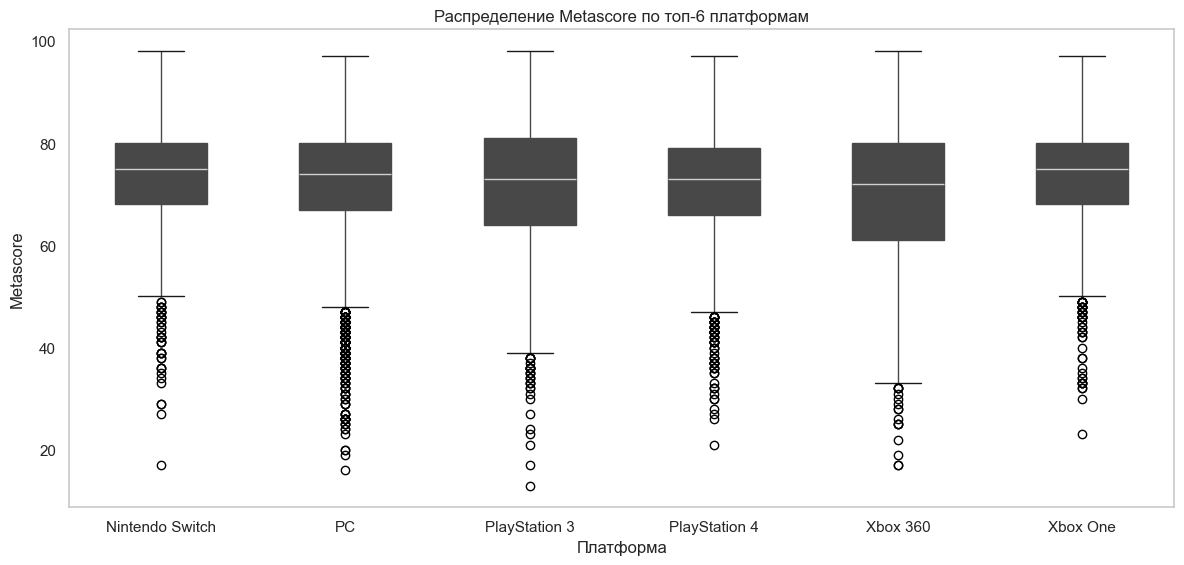

In [21]:
plt.figure(figsize=(12, 6))
df_p.boxplot(column='metascore', by='platform', grid=False,
             patch_artist=True, figsize=(12, 6))
plt.title('Распределение Metascore по топ-6 платформам')
plt.suptitle('')
plt.xlabel('Платформа'); plt.ylabel('Metascore')
plt.tight_layout()
plt.savefig('plot_platform_boxplot.png', dpi=150)
plt.show()


## X. Дополнительный анализ: тренд Metascore по годам

Анализируем динамику среднего Metascore с 1995 по 2025 год.


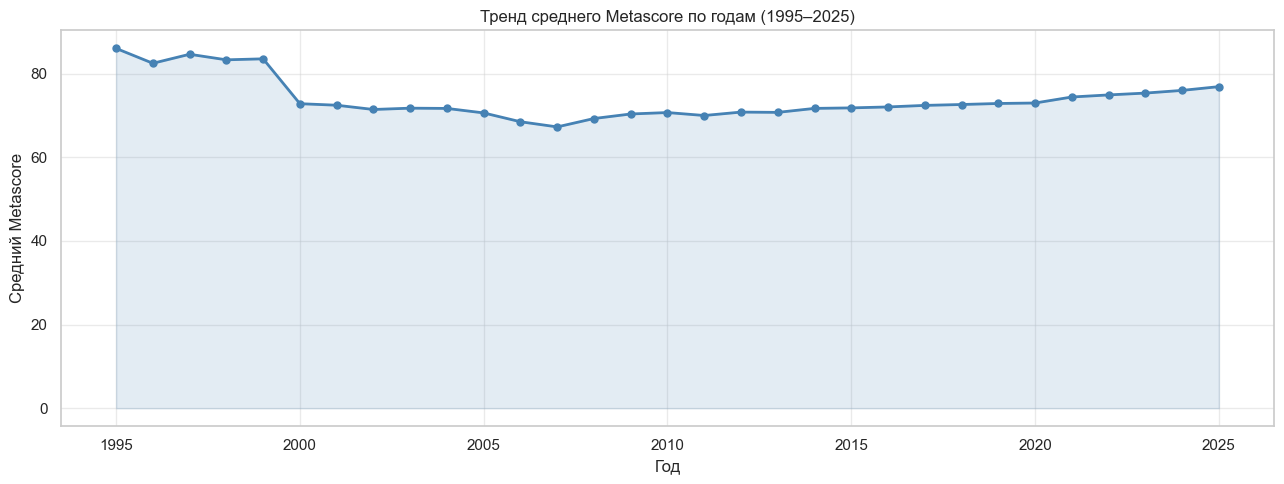


Средний Metascore по 5-летним периодам:
period
1995-2000    76.08
2001-2005    71.48
2006-2010    69.25
2011-2015    71.00
2016-2020    72.56
2021-2025    75.29
Name: metascore, dtype: float64


In [22]:
year_avg = df.groupby('release_year')['metascore'].mean().reset_index()
year_avg = year_avg[(year_avg['release_year'] >= 1995) & (year_avg['release_year'] <= 2025)]

plt.figure(figsize=(13, 5))
plt.plot(year_avg['release_year'], year_avg['metascore'], 
         marker='o', linewidth=2, color='steelblue', markersize=5)
plt.fill_between(year_avg['release_year'], year_avg['metascore'], 
                 alpha=0.15, color='steelblue')
plt.title('Тренд среднего Metascore по годам (1995–2025)')
plt.xlabel('Год'); plt.ylabel('Средний Metascore')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('plot_trend.png', dpi=150)
plt.show()

print("\nСредний Metascore по 5-летним периодам:")
bins = [1994, 2000, 2005, 2010, 2015, 2020, 2026]
labels = ['1995-2000','2001-2005','2006-2010','2011-2015','2016-2020','2021-2025']
df['period'] = pd.cut(df['release_year'], bins=bins, labels=labels)
print(df.groupby('period', observed=True)['metascore'].mean().round(2))


## XI. Итоговая сводка результатов

| Тест | Гипотеза | Результат | Вывод |
|---|---|---|---|
| Шапиро-Уилка | Нормальность Metascore | p < 0.05 | Распределение НЕ нормальное |
| Шапиро-Уилка | Нормальность User Score | p < 0.05 | Распределение НЕ нормальное |
| Pearson/Spearman | Корреляция оценок | r=0.52, p < 0.001 | Значимая положительная корреляция |
| t-тест | Metascore = User×10 | t=28.6, p < 0.001 | Критики оценивают выше пользователей |
| χ² | Независимость категорий | χ²=4677, p < 0.001 | Категории зависимы |
| ANOVA (жанры) | Равенство средних | F=35.9, p < 0.001 | Жанр влияет на оценку |
| ANOVA (платформы) | Равенство средних | F=31.9, p < 0.001 | Платформа влияет на оценку |

**Основные выводы:**
1. Оценки критиков и пользователей умеренно коррелируют (r=0.52), но критики в среднем ставят более высокие оценки
2. Жанр и платформа значимо влияют на Metascore — лидируют Open-World Action и 2D Platformer
3. С 2020 года наблюдается устойчивый рост среднего Metascore, что свидетельствует о росте качества издаваемых игр
4. 47.7% игр получили положительный Metascore (≥75), только 14.2% — отрицательный (<60)
